In [1]:
import torch
import numpy as np
from sbi_particle_physics.objects.model import Model
from sbi_particle_physics.objects.normalizer import Normalizer
from sbi_particle_physics.managers.plotter import Plotter
from sbi_particle_physics.managers.backup import Backup
from sbi_particle_physics.config import DATA_DIR, ACCEPTANCE_COEFFS_PATH

In [2]:
device = "cpu" # this small test works on cpu
n_points = 5
n_samples = 5
model = Model(device, n_points)

model.set_prior_basic([3], [5])
model.set_simulator(stride=2, pre_N=2, preruns=2, use_imperfections=True, acceptance_coeffs_path=ACCEPTANCE_COEFFS_PATH)

raw_data, raw_parameters = model.simulate_raw_data(n_samples=n_samples, n_points=n_points)
model.set_normalizer_with_data(raw_data=raw_data)
model.build_default()
data = model.normalizer.normalize_data(raw_data)
parameters = model.normalizer.normalize_parameters(raw_parameters)
model.append_data(data, parameters)
model.train(max_num_epochs=2, stop_after_epochs=1)
print("All done")

print("normalized stats", data.mean(dim=(0,1)), data.std(dim=(0,1)))

Simulating samples:   0%|          | 0/5 [00:00<?, ?it/s]

/home/hep/nrc25/miniconda3/envs/mlhep/lib/python3.12/site-packages/eos/signal_pdf.py:71: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  log_proposal = pypmc.density.gauss.LocalGauss(sigma)


Pre-runs:   0%|          | 0/2 [00:00<?, ?it/s]

Markov chain self adaptation failed; trying diagonalization
Diagonalization succeeded
Markov chain self adaptation failed; trying diagonalization
Diagonalization succeeded


Main run:   0%|          | 0/100 [00:00<?, ?it/s]

...

Main run:   0%|          | 0/100 [00:00<?, ?it/s]

Pre-runs:   0%|          | 0/2 [00:00<?, ?it/s]

Markov chain self adaptation failed; trying diagonalization
Diagonalization succeeded
Markov chain self adaptation failed; trying diagonalization
Diagonalization succeeded


Main run:   0%|          | 0/100 [00:00<?, ?it/s]

 Training neural network. Epochs trained: 3All done
normalized stats tensor([ 5.7220e-08, -2.8610e-08,  2.1458e-08, -8.1062e-08, -1.4305e-08]) tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [3]:
print("Raw data")
print(raw_data.shape)
print(raw_data[0,:10])
unique_points, counts = torch.unique(
    raw_data[0],
    dim=0,
    return_counts=True
)
print("#unique points", unique_points.shape[0])

print("\nRaw parameters")
print(raw_parameters.shape)
print(raw_parameters[:10])

Raw data
torch.Size([5, 5, 4])
tensor([[13.0826,  0.3930, -0.7025,  2.0840],
        [12.0306,  0.3777, -0.0730,  2.3686],
        [18.3335,  0.3077,  0.1111, -1.3446],
        [ 1.1931,  0.3333,  0.7389,  2.2533],
        [16.4865,  0.6789, -0.4540,  2.1136]])
#unique points 5

Raw parameters
torch.Size([5, 1])
tensor([[3.6115],
        [3.8829],
        [3.5809],
        [4.1695],
        [3.3719]])


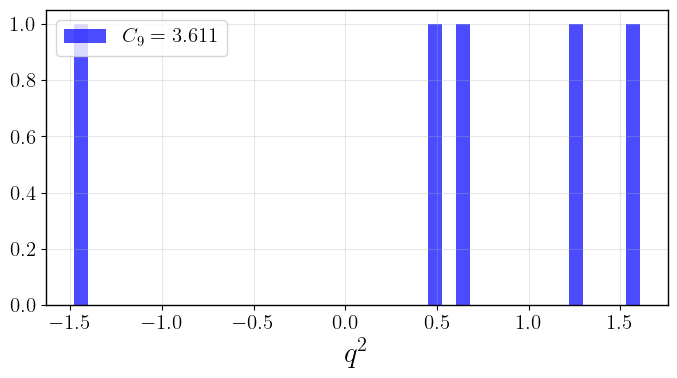

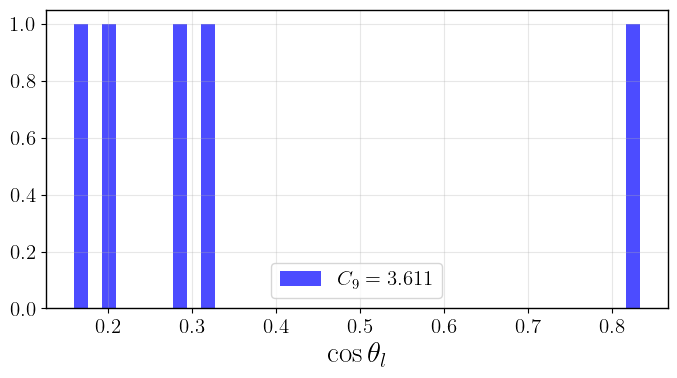

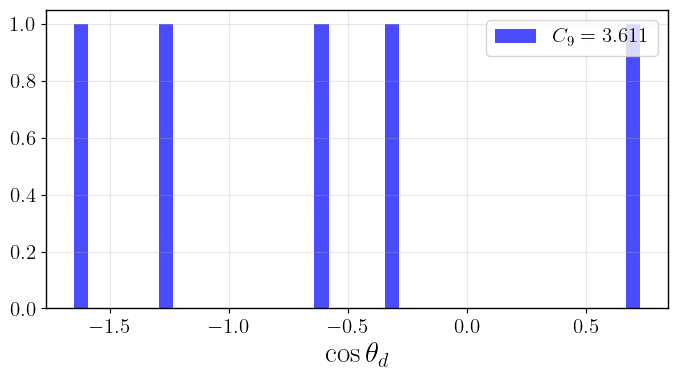

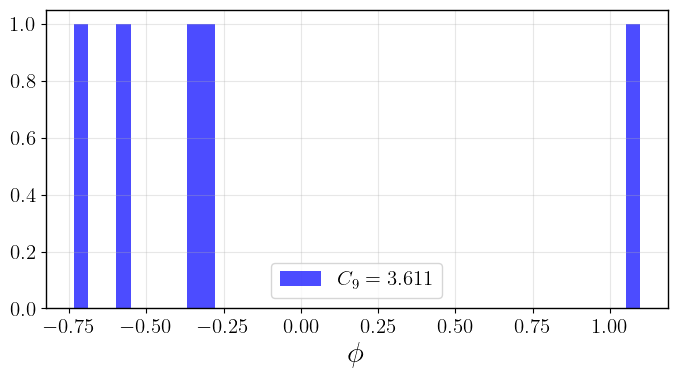

In [5]:
Plotter.plot_a_sample(data[0], parameters[0])